Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, ConcatDataset, random_split
from torchvision import datasets, transforms, models

from helper import make_dataset, train, test, get_indices
import matplotlib.pyplot as plt
import numpy as np

Use device

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


Fill in respective folder location for dataset

In [3]:
import torch
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  
    transforms.RandomRotation(5),      
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_real_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\train\real"
train_fake_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\train\fake"
valid_real_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\valid\real"
valid_fake_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\valid\fake"

train_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\train"
valid_dir = r"C:\SUTD\50.039 Deep Learning\PROJECT\datasetrealfake\DFWILD\valid"

Create train, valid and test datasets and dataloaders

In [4]:

train_dataset = make_dataset(train_dir, 9500, 500, transform)

valid_dataset = make_dataset(valid_dir, 950, 50, transform)

val_size = int(0.5 * len(valid_dataset))
test_size = len(valid_dataset) - val_size

val_dataset, test_dataset = random_split(valid_dataset, [val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

real_count = 0
fake_count = 0

for _, labels in train_loader:
    real_count += (labels == 0).sum().item()
    fake_count += (labels == 1).sum().item()

print("Train real:", real_count)
print("Train fake:", fake_count)



Train real: 9500
Train fake: 500


ResNet18

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Sequential(
    nn.Linear(512, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(0.5),
    nn.Linear(128, 32),
    nn.ReLU(inplace=True),
    nn.Dropout(0.4),
    nn.Linear(32, 2),
)
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer2.parameters():
    param.requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0,19.0]).to(device))
model = model.to(device)
optimizer = optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.layer4.parameters(), 'lr': 1e-5, 'weight_decay': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-4, 'weight_decay': 1e-4}
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)
loss_values, val_accuracies, best_thereshold = train(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=20, scheduler=scheduler)
test(model, test_loader, device, threshold=best_thereshold)


Epoch : 0
Best Threshold : 0.2890
Train Loss     : 0.6074
Validation Accuracy  : 95.00%
F1 Score       : 0.0000
Recall         : 0.0000  <- how many anomalies caught
Precision      : 0.0000
AUC-ROC        : 0.6641

Confusion Matrix:
                 Predicted Real  Predicted Fake
Actual Real      475             0
Actual Fake      25              0
PR-AUC         : 0.1078

Epoch : 1
Best Threshold : 0.3744
Train Loss     : 0.5881
Validation Accuracy  : 95.00%
F1 Score       : 0.0000
Recall         : 0.0000  <- how many anomalies caught
Precision      : 0.0000
AUC-ROC        : 0.8291

Confusion Matrix:
                 Predicted Real  Predicted Fake
Actual Real      475             0
Actual Fake      25              0
PR-AUC         : 0.2729

Epoch : 2
Best Threshold : 0.3505
Train Loss     : 0.5494
Validation Accuracy  : 95.00%
F1 Score       : 0.0000
Recall         : 0.0000  <- how many anomalies caught
Precision      : 0.0000
AUC-ROC        : 0.8560

Confusion Matrix:
              

KeyboardInterrupt: 

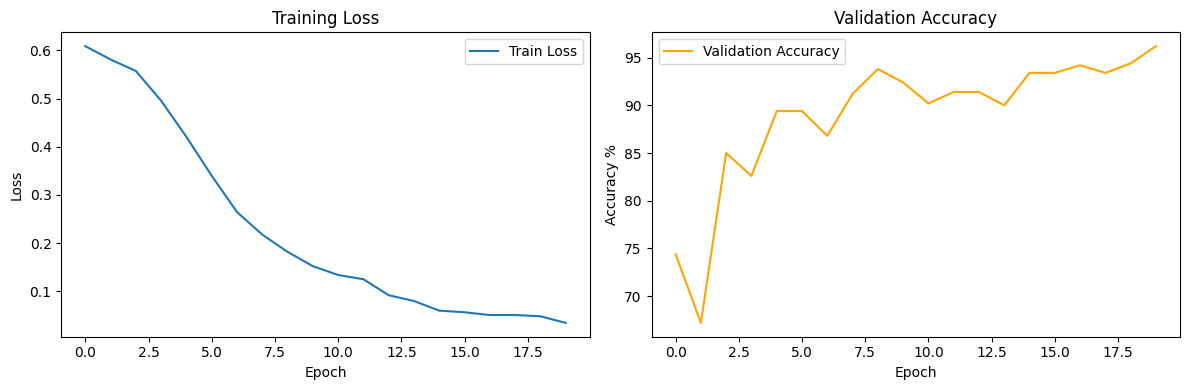

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(loss_values, label='Train Loss')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# Accuracy curve
ax2.plot(val_accuracies, label='Validation Accuracy', color='orange')
ax2.set_title('Validation Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy %')
ax2.legend()

plt.tight_layout()
plt.savefig('training_curves.png')  # saves to file
plt.show()

In [ ]:
from sklearn.metrics import average_precision_score

# Load best model
model.load_state_dict(torch.load('best_model.pth'))

# Test with optimal threshold from PR curve
test(model, test_loader, device, threshold=0.85)

# Test with your current threshold
test(model, test_loader, device, threshold=0.3)

# Test with middle ground
test(model, test_loader, device, threshold=0.5)


C:\Users\thoai\AppData\Local\Temp\ipykernel_26152\1990863805.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pth'))


Test Accuracy  : 95.20%
F1 Score       : 0.0000
Recall         : 0.0000  <- how many anomalies caught
Precision      : 0.0000
AUC-ROC        : 0.9084

Confusion Matrix:
                 Predicted Real  Predicted Fake
Actual Real      476             0
Actual Fake      24              0
Test Accuracy  : 81.40%
F1 Score       : 0.3212
Recall         : 0.9167  <- how many anomalies caught
Precision      : 0.1947
AUC-ROC        : 0.9297

Confusion Matrix:
                 Predicted Real  Predicted Fake
Actual Real      385             91
Actual Fake      2               22
Test Accuracy  : 94.60%
F1 Score       : 0.5424
Recall         : 0.6667  <- how many anomalies caught
Precision      : 0.4571
AUC-ROC        : 0.9213

Confusion Matrix:
                 Predicted Real  Predicted Fake
Actual Real      457             19
Actual Fake      8               16
